# Linear Algebra 

Before diving into the code and intuition here, I **strongly recommend** watching the [Essence of Linear Algebra](https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab) playlist by **3Blue1Brown** on YouTube.

It's a free, series that builds the most important thing in math: **visual intuition**. Most people learn linear algebra as a bunch of rules and formulas — this playlist shows you what's actually *happening*, geometrically. Once you see it, everything clicks.

>  You don't need to finish the whole playlist before starting here — even the first 4-5 videos will make a huge difference.

---

With that foundation, this repository walks through linear algebra **from scratch** — both the intuition behind every concept and the code to implement it. No libraries doing the heavy lifting. Just you, Python, and math.

### Magnitude of a vector

# Magnitude of a Vector

> **Before reading:** If you haven't already, watch the first few videos of [3Blue1Brown's Essence of Linear Algebra](https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab). It builds the visual intuition that makes everything below click instantly.

---

## What is Magnitude?

The magnitude of a vector is simply its **length** — how far it stretches from its tail to its tip. We write it as **|v|**.

The question is: *how do we calculate that length from just the numbers (components) of a vector?*

The answer comes from one of the oldest ideas in geometry — **Pythagoras' theorem**.

---

## Intuition in 2D

Think of a 2D vector like **v = [3, 4]**.

We know two things for free:
- **î** (i-hat) is the unit vector along x — it has length **1**
- **ĵ** (j-hat) is the unit vector along y — it has length **1**

So our vector is just saying: *"go 3 steps in x, then 4 steps in y."*

Now here's the key move — **drop a perpendicular from the tip of the vector straight down to the x-axis.**

What do you get? A right triangle where:
- the **base** is the x component (how far you went along x)
- the **height** is the y component (the perpendicular you just drew)
- the **hypotenuse** is the vector itself — and that's exactly what we want!

Since it's a right triangle, Pythagoras gives us:

$$|\vec{v}| = \sqrt{x^2 + y^2}$$

That's it. The magnitude is just the hypotenuse of the right triangle formed by the two components.

---

## Intuition in 3D

Now add a third dimension. Our vector is **v = [2, 3, 2]** — it goes somewhere in 3D space.

We can't directly apply Pythagoras to three things at once, but we can be clever about it — **apply it twice**.

**Step 1 — Take the shadow.**

Imagine shining a light straight down from above. The vector casts a **shadow onto the xz plane** (the floor). This shadow completely ignores the y component — it's as if you're looking at the vector from directly above and only seeing where it lands on the floor.

This shadow is a 2D vector with components x and z. Just like in 2D, drop a perpendicular and apply Pythagoras:

$$d = \sqrt{x^2 + z^2}$$

Now you have **d** — the length of the shadow (the floor diagonal).

**Step 2 — Stand it back up.**

Now forget about x and z separately. You have:
- **d** — the length of the shadow (one leg of a new right triangle)
- **y** — the perpendicular height from the floor up to the vector tip (other leg)
- **|v|** — the actual 3D vector (the hypotenuse you want)

Apply Pythagoras one more time:

$$|\vec{v}| = \sqrt{d^2 + y^2} = \sqrt{(\sqrt{x^2 + z^2})^2 + y^2} = \sqrt{x^2 + y^2 + z^2}$$

And that's why the 3D magnitude formula looks the way it does — it's just **Pythagoras applied twice**, once on the floor and once standing up.

---

## General Formula (any dimension)

This pattern extends to any number of dimensions. For a vector **v = [x₁, x₂, ..., xₙ]**:

$$|\vec{v}| = \sqrt{x_1^2 + x_2^2 + \dots + x_n^2} = \sqrt{\sum_{i=1}^{n} x_i^2}$$

Each dimension just adds another term under the square root — you're always finding the hypotenuse of a right triangle formed by "everything so far" and the new component.


### Will be adding visualization soon

If anyone wants me to do everything other than the intuition from scratch ill do it:

ex. sqrt , array and all..

In [1]:
import numpy as np

In [2]:
##2D
v1 = np.array([1,2])
value = v1[0]**2 +v1[1]**2
magnitude = np.sqrt(value)
print(f"magnitude of {v1} is {magnitude}")

magnitude of [1 2] is 2.23606797749979


In [3]:
##3D
##manual way for intuition
v2 = np.array([2,3,2])
projected_v2= v2[0]**2+v2[2]**2
projected = np.sqrt(projected_v2)
magnitude_v2 = projected**2+v2[1]**2
real_magnitude = np.sqrt(magnitude_v2)
print(f"first projected xz {projected} then second pythagoras {real_magnitude}")

first projected xz 2.8284271247461903 then second pythagoras 4.123105625617661


In [4]:
### faster way using library
v2 = np.array([2,3,2])
projected_v2= v2[0]**2+v2[1]**2+v2[2]**2
projected = np.sqrt(projected_v2)
print(f"{projected:.3f}")

4.123


# Normalizing a Vector

> **Normalization** = shrinking (or stretching) a vector so its magnitude becomes exactly **1**, without changing the direction it points.

## How to Normalize

To normalize a vector **v**, just divide every component by its magnitude:

$$\hat{v} = \frac{\vec{v}}{|\vec{v}|}$$

That's it. You're scaling the vector down (or up) so it lands exactly on the unit circle (in 2D) or unit sphere (in 3D).

**Example** — v = [3, 4]:

$$|\vec{v}| = \sqrt{3^2 + 4^2} = \sqrt{25} = 5$$

$$\hat{v} = \left[\frac{3}{5},\ \frac{4}{5}\right] = [0.6,\ 0.8]$$

Check: $\sqrt{0.6^2 + 0.8^2} = \sqrt{0.36 + 0.64} = \sqrt{1} = 1$ ✓

The direction is identical to the original — the vector just got scaled to length 1.

---

## Why Does This Work?

Think about it geometrically. If you divide a vector by its own length, you're asking: *"what fraction of my total length is each component?"*

The result always lands on the unit circle/sphere because you're normalizing the total stretch to 1. No matter how big or small the original vector was, after normalization it always sits on that boundary.

> **One edge case** — you can never normalize the zero vector **[0, 0, 0]** because dividing by zero is undefined. The zero vector has no direction, so normalization makes no sense for it.

---

## Applications

Machine Learning — Cosine Similarity

--We will learn more about this further.

NLP — Word Vectors

--further...



In [5]:
v = np.array([3, 4])

sum_of_squares = sum(x**2 for x in v)
magnitude      = np.sqrt(sum_of_squares)
unit_vector    = v / magnitude

print(f"original vector   : {v}")
print(f"magnitude         : {magnitude}")
print(f"normalized vector : {unit_vector}")
print(f"verify magnitude  : {np.sqrt(sum(x**2 for x in unit_vector)):.1f}")  # should be 1.0

original vector   : [3 4]
magnitude         : 5.0
normalized vector : [0.6 0.8]
verify magnitude  : 1.0


In [6]:
x1 = np.array([1,2,3])
x2 = np.array([4,5,6])


In [7]:
##will come later

In [8]:
print(x1+x2)

[5 7 9]


In [9]:
print(x1*x2)

[ 4 10 18]


In [10]:
print(x2/x1)

[4.  2.5 2. ]


In [11]:
x3 = np.array([[1,2,3],[3,4,5],[6,7,8]])

In [12]:
print(x3*3)

[[ 3  6  9]
 [ 9 12 15]
 [18 21 24]]


In [13]:
print(x3/4)

[[0.25 0.5  0.75]
 [0.75 1.   1.25]
 [1.5  1.75 2.  ]]


In [14]:
print(x3+3)

[[ 4  5  6]
 [ 6  7  8]
 [ 9 10 11]]


In [15]:
print(x3*x1)

[[ 1  4  9]
 [ 3  8 15]
 [ 6 14 24]]


In [16]:
print(x1*x3)

[[ 1  4  9]
 [ 3  8 15]
 [ 6 14 24]]


In [17]:
print(x1*x2*x3)

[[  4  20  54]
 [ 12  40  90]
 [ 24  70 144]]


# Transpose of a Matrix

## What is Transpose?

Given a matrix **A**, its transpose **Aᵀ** is obtained by simply **swapping rows and columns** — every row becomes a column and every column becomes a row.

More precisely, if element **A[i][j]** is at row **i** and column **j**, after transposing it moves to position **[j][i]** in **Aᵀ**.

$$A[i][j] \rightarrow A^T[j][i]$$

---

## Visualizing It

Think of the matrix as a grid of numbers. Taking the transpose is like **flipping that grid along its main diagonal** — the diagonal line running from the top-left to the bottom-right corner. Every element reflects across that line.

```
A = [[1, 2, 3],          Aᵀ = [[1, 4],
     [4, 5, 6]]                 [2, 5],
                                [3, 6]]
```

Notice what happened:
- Row 1 of A → Column 1 of Aᵀ
- Row 2 of A → Column 2 of Aᵀ

> The elements sitting **on the diagonal** (positions [0,0], [1,1], [2,2] ...) never move — they lie exactly on the flip axis, so they stay in place.

---

## Shape Changes

This is important — transpose **changes the shape** of a matrix.

| Original Shape | Transposed Shape |
|:-:|:-:|
| (2 × 3) | (3 × 2) |
| (1 × 4) row vector | (4 × 1) column vector |
| (3 × 3) square | (3 × 3) square (same shape, values rearrange) |

An **(m × n)** matrix always becomes **(n × m)** after transpose. Square matrices keep their shape but their values shuffle across the diagonal.

---

## Properties

**Double transpose gives you back the original:**
$$( A^T )^T = A$$

**Transpose of a sum:**
$$(A + B)^T = A^T + B^T$$

**Transpose of a product (order flips!):**
$$(AB)^T = B^T A^T$$

This last one is subtle — when you transpose a product, the order of the matrices **reverses**. This matters a lot when working with chains of matrices.

---

## Special Case — Symmetric Matrices

A matrix is called **symmetric** if it equals its own transpose:

$$A = A^T$$

This only happens with square matrices where **A[i][j] = A[j][i]** for every element — meaning the matrix is already a mirror image of itself across the diagonal.

```
A = [[1, 2, 3],      Aᵀ = [[1, 2, 3],
     [2, 5, 4],             [2, 5, 4],    →  A = Aᵀ  ✓
     [3, 4, 6]]             [3, 4, 6]]
```


In [18]:
# Transpose of a matrix
A = [
    [1, 2, 3],
    [4, 5, 6]
]
rows = len(A)
cols = len(A[0])

In [19]:
rows , cols

(2, 3)

Python evaluates this as:

[0] * 2  →  [0, 0]



list * n means repeat the list n times

So:

[0] * 1 → [0]

[0] * 2 → [0, 0]

[0] * 3 → [0, 0, 0]

In [20]:
# STEP 1 - creates [[0,0],[0,0],[0,0]]
result = []
for c in range(cols):
    result.append([0] * rows) #0 * rows basically 

# STEP 2 - your fill loop
for i in range(cols):
    for j in range(rows):
        result[i][j] = A[j][i]  # FILLS existing slots

In [21]:
result

[[1, 4], [2, 5], [3, 6]]

In [22]:
at = np.array(A).T

In [23]:
at

array([[1, 4],
       [2, 5],
       [3, 6]])

# Determinant of a Matrix

## What is the Determinant?

When a matrix transforms space, every shape in that space gets stretched, squished, or flipped. The **determinant** tells you exactly **by how much the area (or volume) gets scaled** after that transformation.

For a 2D matrix, think of the two column vectors as defining a parallelogram. The determinant is the **area of that parallelogram**.

$$A = \begin{bmatrix} a & b \\ c & d \end{bmatrix} \quad \Rightarrow \quad \det(A) = ad - bc$$

But where does **ad - bc** actually come from? Let's derive it geometrically.

---

## Geometric Derivation of the Formula

Take a matrix:

$$A = \begin{bmatrix} a & b \\ c & d \end{bmatrix}$$

The two column vectors are **v₁ = (a, c)** and **v₂ = (b, d)**. These two vectors define a parallelogram. We want to find its area.

> The image below (from 3Blue1Brown) shows exactly this — the parallelogram sitting inside the bounding rectangle, with the pink rectangles and teal triangles being the pieces we subtract.

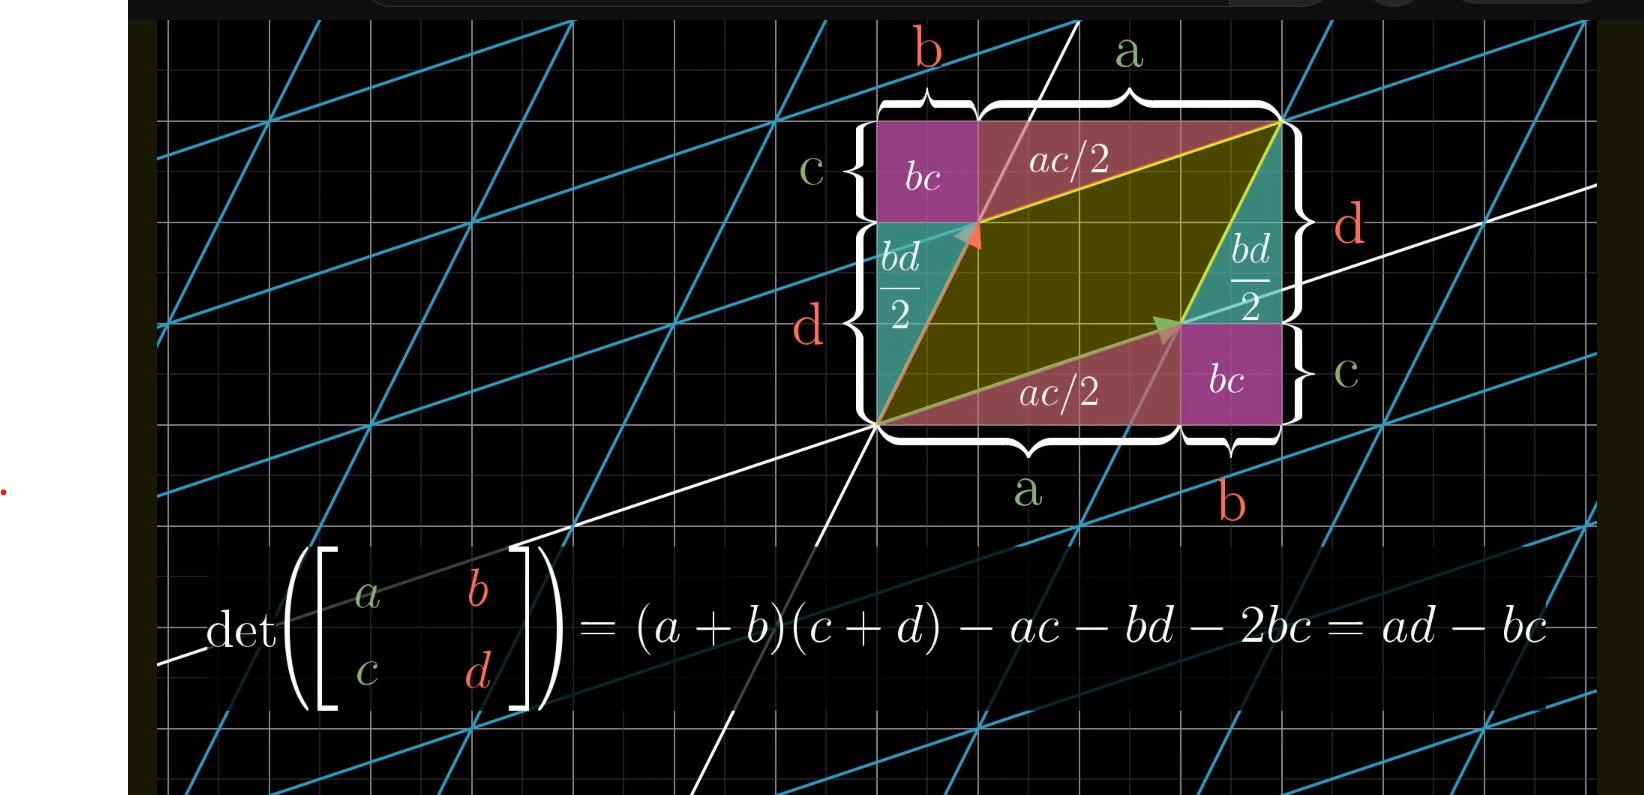
**Step 1 — Draw a bounding rectangle.**

Place the parallelogram inside a rectangle of width **(a + b)** and height **(c + d)**.

```
(0, c+d) ─────────────── (a+b, c+d)
    |                          |
    |                          |
(0,  0)  ─────────────── (a+b,  0)
```

Area of the big rectangle = **(a + b)(c + d)**

Expanding:

$$= ac + ad + bc + bd$$

**Step 2 — Subtract the pieces that aren't part of the parallelogram.**

Looking at the bounding rectangle, there are pieces surrounding the parallelogram that need to be removed:

- **2 corner triangles** (top-left and bottom-right), each with area **ac/2** → together: **ac**
- **2 corner triangles** (top-right and bottom-left), each with area **bd/2** → together: **bd**
- **2 rectangles** on the sides, each with area **bc** → together: **2bc**

**Step 3 — Subtract them all from the big rectangle:**

$$\text{Area of parallelogram} = (a+b)(c+d) - ac - bd - 2bc$$

Expanding **(a+b)(c+d)**:

$$= ac + ad + bc + bd - ac - bd - 2bc$$

$$= ad - bc$$

And there it is — **ad - bc** comes directly from the geometry of subtracting everything outside the parallelogram from the bounding rectangle.

$$\boxed{\det(A) = ad - bc}$$

---

## What the Determinant Tells You

**det > 0** — Space got scaled up, orientation preserved

**det < 0** — Space got scaled, but also **flipped** (like a mirror reflection). The absolute value still gives you the area, the sign tells you orientation flipped.

**det = 0** — The two vectors are **parallel** — the parallelogram collapses into a line. No area. This means the transformation squishes space into a lower dimension and **cannot be reversed**.

**|det| = 1** — Area is perfectly preserved (no scaling), just rotation or reflection.

---

## Extending to 3D

In 3D, the determinant gives the **volume of the parallelepiped** (the 3D version of a parallelogram) formed by the three column vectors.

$$A = \begin{bmatrix} a & b & c \\ d & e & f \\ g & h & i \end{bmatrix}$$

$$\det(A) = a(ei - fh) - b(di - fg) + c(dh - eg)$$

Notice the pattern — you're expanding along the first row, and each term is the element multiplied by the determinant of the **2×2 matrix** that remains after removing that element's row and column. This is called **cofactor expansion**.

---

## Properties

**Determinant of identity is 1** — no scaling, space unchanged:
$$\det(I) = 1$$

**Determinant of a product** — scales multiply:
$$\det(AB) = \det(A) \cdot \det(B)$$

**Determinant of transpose** — same value:
$$\det(A^T) = \det(A)$$

**Determinant of inverse** — reciprocal:
$$\det(A^{-1}) = \frac{1}{\det(A)}$$

**Swapping two rows flips the sign:**
$$\det = 2 \quad \xrightarrow{\text{swap rows}} \quad \det = -2$$

**If any row is all zeros, det = 0** — the transformation collapses space.


In [24]:
A = [
    [4, 7],
    [2, 6]
]

a = A[0][0]
b = A[0][1]
c = A[1][0]
d = A[1][1]

det = (a * d) - (b * c)
print(det)

10


# Inverse of a Matrix

## What is the Inverse?

When a matrix **A** transforms space — moving î and ĵ to new positions — its inverse **A⁻¹** is the transformation that **undoes** that completely, bringing everything back to where it started.

Mathematically, applying A then A⁻¹ is the same as doing nothing:

$$A \cdot A^{-1} = A^{-1} \cdot A = I$$

Where **I** is the identity matrix — the transformation that leaves all vectors exactly where they are.

$$I = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$$

---

## When Does the Inverse Exist?

The inverse only exists when **det(A) ≠ 0**.

Think about why. If the determinant is zero, the transformation squished space into a lower dimension — a 2D plane got collapsed into a line, or a line got collapsed into a point. Once that squishing happens, information is permanently lost. Multiple different vectors all landed on the same point, so there is no way to know which one to go back to. The transformation is irreversible.

When **det(A) ≠ 0**, nothing got squished. The transformation just rotated, stretched, or sheared space — all of which are reversible.

| det(A) | Inverse |
|:-:|:-:|
| ≠ 0 | exists ✓ |
| = 0 | does not exist ✗ |

A matrix with no inverse is called **singular**. A matrix with an inverse is called **non-singular** or **invertible**.

---

## Formula for 2×2 Inverse

$$A = \begin{bmatrix} a & b \\ c & d \end{bmatrix} \quad \Rightarrow \quad A^{-1} = \frac{1}{ad-bc} \begin{bmatrix} d & -b \\ -c & a \end{bmatrix}$$

Three things happen here:

1. **Swap the diagonal** — a and d swap positions
2. **Negate the off-diagonal** — b and c flip their signs
3. **Divide everything by the determinant** — this is the scaling factor that makes it all work out

Notice **ad - bc** in the denominator — that's exactly the determinant. If det = 0, you're dividing by zero, which is why no inverse exists.

---

## Verifying It

Multiply A by A⁻¹ and confirm you get I:

$$\begin{bmatrix} a & b \\ c & d \end{bmatrix} \cdot \frac{1}{ad-bc}\begin{bmatrix} d & -b \\ -c & a \end{bmatrix}$$

$$= \frac{1}{ad-bc} \begin{bmatrix} ad-bc & -ab+ab \\ cd-cd & -bc+ad \end{bmatrix}$$

$$= \frac{1}{ad-bc} \begin{bmatrix} ad-bc & 0 \\ 0 & ad-bc \end{bmatrix}$$

$$= \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix} = I \quad ✓$$

---

## Properties

**A times its inverse is identity:**
$$A \cdot A^{-1} = I$$

**Inverse of a product — order flips, just like transpose:**
$$(AB)^{-1} = B^{-1}A^{-1}$$

**Inverse of a transpose:**
$$(A^T)^{-1} = (A^{-1})^T$$

**Inverse of the inverse gives back the original:**
$$(A^{-1})^{-1} = A$$

**Determinant of the inverse is the reciprocal:**
$$\det(A^{-1}) = \frac{1}{\det(A)}$$





In [25]:
inverse = [[d/det ,-(b)/det],[-(c)/det,a/det]]

In [26]:
inverse

[[0.6, -0.7], [-0.2, 0.4]]

In [27]:
import numpy as np

a_i = np.linalg.inv(A)


In [28]:
a_i

array([[ 0.6, -0.7],
       [-0.2,  0.4]])

# Dot Product

## What is the Dot Product?

The dot product takes two vectors and collapses them into a single number — a **scalar**. That number captures how much the two vectors "agree" in direction.

More precisely, the dot product is the **length of the projection of one vector onto the other, multiplied by the magnitude of that other vector**.

$$\vec{u} \cdot \vec{v} = |\vec{u}|\ \times\ \text{(projection of } \vec{v} \text{ onto } \vec{u})$$

---

## The Two Formulas

**Algebraic — component wise:**

$$\vec{u} \cdot \vec{v} = u_x v_x + u_y v_y$$

In n dimensions:

$$\vec{u} \cdot \vec{v} = \sum_{i=1}^{n} u_i v_i$$

**Geometric — using the angle between them:**

$$\vec{u} \cdot \vec{v} = |\vec{u}|\ |\vec{v}|\ \cos\theta$$

Where **θ** is the angle between the two vectors. Both formulas always give the same result — they are two ways of saying the same thing.

---

## Intuition — What the Sign Tells You

The sign of the dot product comes entirely from **cos θ**:

| Angle between vectors | cos θ | Dot product | Meaning |
|:-:|:-:|:-:|:-|
| θ < 90° | positive | positive | vectors point roughly the same way |
| θ = 90° | 0 | 0 | vectors are perpendicular — no agreement |
| θ > 90° | negative | negative | vectors point roughly opposite ways |
| θ = 0° | 1 | \|u\|\|v\| | vectors point exactly the same way |
| θ = 180° | -1 | -\|u\|\|v\| | vectors point exactly opposite |


> Two vectors are **perpendicular** if and only if their dot product is **0**. This is one of the most used facts in all of linear algebra.

---

## The Projection Connection

Drop a perpendicular from the tip of **v** onto the line of **u**. The length of that shadow is the **scalar projection** of v onto u:

$$\text{scalar projection} = |\vec{v}|\ \cos\theta = \frac{\vec{u} \cdot \vec{v}}{|\vec{u}|}$$

The dot product is just this projection scaled up by **|u|**. So when **u** is a unit vector (|u| = 1), the dot product gives you the projection directly — which is why normalized vectors are so useful.

---

## Deriving the Geometric Formula

Start with the **law of cosines**. For a triangle formed by vectors **u**, **v**, and **u - v**:

$$|\vec{u} - \vec{v}|^2 = |\vec{u}|^2 + |\vec{v}|^2 - 2|\vec{u}||\vec{v}|\cos\theta$$

Expand the left side using components:

$$|\vec{u} - \vec{v}|^2 = (u_x - v_x)^2 + (u_y - v_y)^2$$
$$= u_x^2 - 2u_xv_x + v_x^2 + u_y^2 - 2u_yv_y + v_y^2$$
$$= |\vec{u}|^2 + |\vec{v}|^2 - 2(u_xv_x + u_yv_y)$$

Comparing both sides:

$$|\vec{u}|^2 + |\vec{v}|^2 - 2(u_xv_x + u_yv_y) = |\vec{u}|^2 + |\vec{v}|^2 - 2|\vec{u}||\vec{v}|\cos\theta$$

$$\boxed{u_xv_x + u_yv_y = |\vec{u}||\vec{v}|\cos\theta}$$

The algebraic and geometric formulas are the same thing.

---

## Properties

**Commutative:**
$$\vec{u} \cdot \vec{v} = \vec{v} \cdot \vec{u}$$

**Distributive over addition:**
$$\vec{u} \cdot (\vec{v} + \vec{w}) = \vec{u} \cdot \vec{v} + \vec{u} \cdot \vec{w}$$

**Dot product with itself = squared magnitude:**
$$\vec{v} \cdot \vec{v} = |\vec{v}|^2$$

**Scaling:**
$$(c\vec{u}) \cdot \vec{v} = c(\vec{u} \cdot \vec{v})$$



In [29]:
result = np.dot(A,inverse)

In [30]:
print(result)

[[ 1.00000000e+00  3.33066907e-16]
 [-1.11022302e-16  1.00000000e+00]]
